# Lab 1 — Single-Node Perceptron

A single sigmoid node (no hidden layer) trained on:

- **AND** — linearly separable, so the perceptron learns it.
- **XOR** — not linearly separable, so the same perceptron cannot learn it.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from neural_network.activations import ACTIVATIONS
from neural_network.hyperparameters import random_weights, zero_bias
from neural_network.layer import Layer
from neural_network.network import Network
from trainer.reporter import Reporter
from trainer.trainer import Trainer
from visualizer import GateVisualizer

from data import AND_INPUTS, AND_TARGETS, XOR_INPUTS, XOR_TARGETS


def build_perceptron() -> Network:
    layer = Layer.build(
        input_size=2, output_size=1,
        weight=random_weights(input_size=2, output_size=1), bias=zero_bias(1),
        activation_function=ACTIVATIONS.SIGMOID.function,
        activation_derivative=ACTIVATIONS.SIGMOID.derivative,
    )
    return Network(layer)

## AND gate

AND is linearly separable — a single node can draw one line that puts `(1, 1)` on
one side and the other three points on the other.

In [2]:
and_network = build_perceptron()
and_trainer = Trainer(and_network)
and_trainer.train(AND_INPUTS, AND_TARGETS)

Epoch: 100/500 | Average Error: 0.022225342910741176
Epoch: 200/500 | Average Error: 0.010415240896792827
Epoch: 300/500 | Average Error: 0.006653163607394102
Epoch: 400/500 | Average Error: 0.004846291572458525
Epoch: 500/500 | Average Error: 0.0037948498210244215
Reached maximum epochs without meeting the error threshold.

Final Error:
Epoch: 500/500 | Average Error: 0.0037948498210244215


In [3]:
Reporter.report(and_network, AND_INPUTS, AND_TARGETS)


Layer 0 weights:
[[5.116841052768, 5.1096034493723135]]
Layer 0 bias:
[-7.7510213922747955]

Inputs: [0, 0] | Target: [0] | Prediction: [0.0004301177272144082]
Inputs: [0, 1] | Target: [0] | Prediction: [0.06651993422763675]
Inputs: [1, 0] | Target: [0] | Prediction: [0.06697076589809602]
Inputs: [1, 1] | Target: [1] | Prediction: [0.9224008280201809]


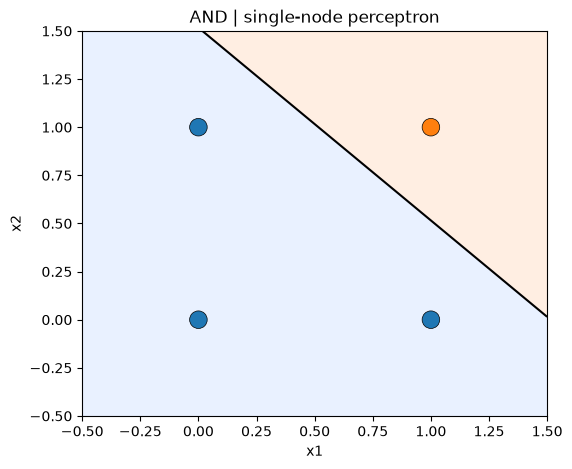

<Axes: title={'center': 'AND | single-node perceptron'}, xlabel='x1', ylabel='x2'>

In [4]:
GateVisualizer().plot(and_network, AND_INPUTS, AND_TARGETS, title="AND | single-node perceptron")

## XOR gate — where a single node fails

XOR is not linearly separable: no single straight line separates `{(0,1), (1,0)}`
from `{(0,0), (1,1)}`. A single node, no matter how it's trained, can only draw one
straight decision line, so it cannot solve XOR — this is the same architecture as
above, just trained on XOR data.

In [5]:
xor_network = build_perceptron()
xor_trainer = Trainer(xor_network)
xor_trainer.train(XOR_INPUTS, XOR_TARGETS)

Epoch: 100/500 | Average Error: 0.299537808739591
Epoch: 200/500 | Average Error: 0.29955840336640716
Epoch: 300/500 | Average Error: 0.29955861687290064
Epoch: 400/500 | Average Error: 0.2995586191819984
Epoch: 500/500 | Average Error: 0.2995586192070807
Reached maximum epochs without meeting the error threshold.

Final Error:
Epoch: 500/500 | Average Error: 0.2995586192070807


In [6]:
Reporter.report(xor_network, XOR_INPUTS, XOR_TARGETS)


Layer 0 weights:
[[-0.3796921795425549, -0.1898460897273118]]
Layer 0 bias:
[0.18984608970440878]

Inputs: [0, 0] | Target: [0] | Prediction: [0.5473194854727158]
Inputs: [0, 1] | Target: [1] | Prediction: [0.49999999999427425]
Inputs: [1, 0] | Target: [1] | Prediction: [0.4526805144941493]
Inputs: [1, 1] | Target: [0] | Prediction: [0.40620114175653305]


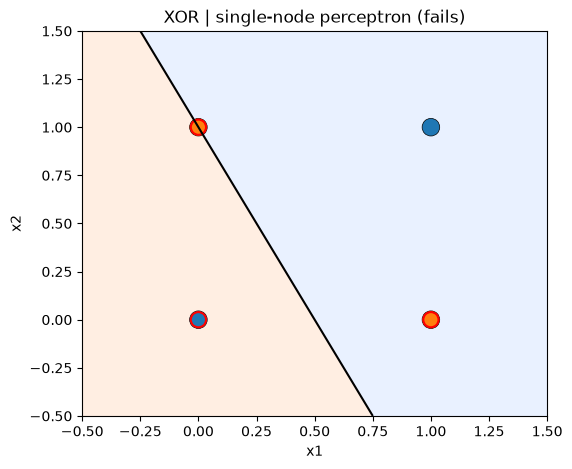

<Axes: title={'center': 'XOR | single-node perceptron (fails)'}, xlabel='x1', ylabel='x2'>

In [7]:
GateVisualizer().plot(xor_network, XOR_INPUTS, XOR_TARGETS, title="XOR | single-node perceptron (fails)")